# Clustering Customers — KMeans y CJ

Dataset: [Shop Customer Data (Kaggle)](https://www.kaggle.com/datasets/datascientistanna/customers-dataset)

1. Elegimos **k** con el **codo de Jambú** (silueta de apoyo).  
2. Tuning: **KMeans** y **Clustering Jerárquico**.  
3. Mejor modelo por **índice de silueta**.  
4. Visualizamos: silueta, **PCA** y **radar**.

Features: numéricas + **Gender** + **Profession (dummies)**.


In [ ]:
import itertools
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

## 1. Cargar y preparar datos

In [ ]:
df = pd.read_csv("Customers.csv")

num_features = [
    "Age",
    "Annual Income ($)",
    "Spending Score (1-100)",
    "Work Experience",
    "Family Size",
]
df = df[num_features]
features = df.columns.tolist()

X = StandardScaler().fit_transform(df.values.astype(float))

print(f"Clientes: {len(df)} | Variables: {len(features)}")
print("Numéricas:", num_features)
print("Dummies:", list(dummies.columns))
df_feat.head()


Clientes: 2000 | Variables: 5
Numéricas: ['Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Work Experience', 'Family Size']
Dummies: ['Gender_Female', 'Gender_Male', 'Prof_Artist', 'Prof_Doctor', 'Prof_Engineer', 'Prof_Entertainment', 'Prof_Executive', 'Prof_Healthcare', 'Prof_Homemaker', 'Prof_Lawyer', 'Prof_Marketing', 'Prof_Unknown']


,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size,Gender_Female,Gender_Male,Prof_Artist,Prof_Doctor,Prof_Engineer,Prof_Entertainment,Prof_Executive,Prof_Healthcare,Prof_Homemaker,Prof_Lawyer,Prof_Marketing,Prof_Unknown
0,19,15000,39,1,4,False,True,False,False,False,False,False,True,False,False,False,False
1,21,35000,81,3,3,False,True,False,False,True,False,False,False,False,False,False,False
2,20,86000,6,1,1,True,False,False,False,True,False,False,False,False,False,False,False
3,23,59000,77,0,2,True,False,False,False,False,False,False,False,False,True,False,False
4,31,38000,40,2,6,True,False,False,False,False,True,False,False,False,False,False,False


## 2. Codo de Jambú — elegir k

El **codo** es el k más lejos de la línea entre el primer y el último punto de la curva de inercia.

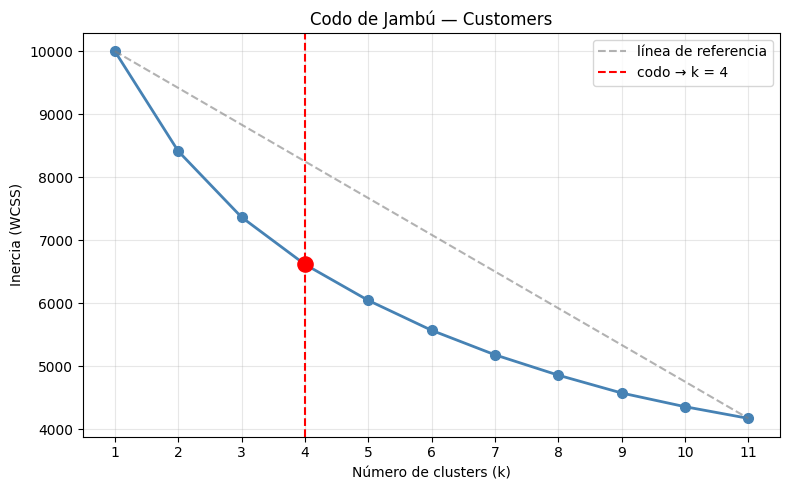

k óptimo (codo de Jambú): 4


In [ ]:
K_CANDIDATOS = list(range(1, 12))
inercias = []

for k in K_CANDIDATOS:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    km.fit(X)
    inercias.append(km.inertia_)

inercias = np.array(inercias)
ks = np.array(K_CANDIDATOS, dtype=float)

p1 = np.array([ks[0], inercias[0]])
p2 = np.array([ks[-1], inercias[-1]])
line = p2 - p1
line_norm = np.linalg.norm(line)

distancias = [
    np.abs(np.cross(line, p1 - np.array([ks[i], inercias[i]]))) / line_norm
    for i in range(len(ks))
]

K_OPTIMO = int(K_CANDIDATOS[int(np.argmax(distancias))])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_CANDIDATOS, inercias, "o-", color="steelblue", linewidth=2, markersize=7)
ax.plot([ks[0], ks[-1]], [inercias[0], inercias[-1]], "--", color="gray", alpha=0.6, label="línea de referencia")
ax.axvline(K_OPTIMO, color="red", linestyle="--", linewidth=1.5, label=f"codo → k = {K_OPTIMO}")
ax.scatter([K_OPTIMO], [inercias[K_CANDIDATOS.index(K_OPTIMO)]], color="red", s=120, zorder=5)
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inercia (WCSS)")
ax.set_title("Codo de Jambú — Customers")
ax.set_xticks(K_CANDIDATOS)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"k óptimo (codo de Jambú): {K_OPTIMO}")

## 3. Tuning — KMeans y Clustering Jerárquico

Con **k fijo** del codo. El ganador se elige por **silueta**.

In [ ]:
resultados = []

# --- KMeans ---
for init, n_init, max_iter, algo in itertools.product(
    ["k-means++", "random"],
    [10, 20, 50],
    [100, 300, 500],
    ["lloyd", "elkan"],
):
    km = KMeans(
        n_clusters=K_OPTIMO,
        init=init,
        n_init=n_init,
        max_iter=max_iter,
        algorithm=algo,
        random_state=RANDOM_STATE,
    )
    labels = km.fit_predict(X)
    resultados.append({
        "modelo": "KMeans",
        "params": {"init": init, "n_init": n_init, "max_iter": max_iter, "algorithm": algo},
        "silueta": silhouette_score(X, labels),
        "labels": labels.copy(),
    })

# --- Clustering Jerárquico (CJ) ---
for linkage, metric in itertools.product(
    ["ward", "complete", "average"],
    ["euclidean", "manhattan", "cosine"],
):
    if linkage == "ward" and metric != "euclidean":
        continue
    cj = AgglomerativeClustering(n_clusters=K_OPTIMO, linkage=linkage, metric=metric)
    labels = cj.fit_predict(X)
    resultados.append({
        "modelo": "CJ",
        "params": {"linkage": linkage, "metric": metric},
        "silueta": silhouette_score(X, labels),
        "labels": labels.copy(),
    })

print(f"Configs evaluadas: {len(resultados)}")

Configs evaluadas: 43


## 4. Ranking y mejor modelo

In [ ]:
ranking = pd.DataFrame([
    {"modelo": r["modelo"], "silueta": r["silueta"], "params": str(r["params"])}
    for r in resultados
]).sort_values("silueta", ascending=False).reset_index(drop=True)

print("=== TOP 10 ===")
display(ranking.head(10))

print("\n=== Mejor por modelo ===")
display(ranking.groupby("modelo", as_index=False).first())

=== TOP 10 ===


,modelo,silueta,params
0,KMeans,0.148137,"{'init': 'k-means++', 'n_init': 10, 'max_iter'..."
1,KMeans,0.148137,"{'init': 'k-means++', 'n_init': 10, 'max_iter'..."
2,KMeans,0.148137,"{'init': 'k-means++', 'n_init': 10, 'max_iter'..."
3,KMeans,0.148137,"{'init': 'k-means++', 'n_init': 10, 'max_iter'..."
4,KMeans,0.148137,"{'init': 'k-means++', 'n_init': 10, 'max_iter'..."
5,KMeans,0.148137,"{'init': 'k-means++', 'n_init': 10, 'max_iter'..."
6,KMeans,0.148137,"{'init': 'k-means++', 'n_init': 20, 'max_iter'..."
7,KMeans,0.148137,"{'init': 'k-means++', 'n_init': 20, 'max_iter'..."
8,KMeans,0.148137,"{'init': 'k-means++', 'n_init': 20, 'max_iter'..."
9,KMeans,0.148137,"{'init': 'k-means++', 'n_init': 20, 'max_iter'..."



=== Mejor por modelo ===


,modelo,silueta,params
0,CJ,0.114420,"{'linkage': 'average', 'metric': 'cosine'}"
1,KMeans,0.148137,"{'init': 'k-means++', 'n_init': 10, 'max_iter'..."


In [ ]:
mejor = max(resultados, key=lambda r: r["silueta"])
labels_final = mejor["labels"]
df["cluster"] = labels_final

print("MEJOR MODELO")
print(f"  Algoritmo : {mejor['modelo']}")
print(f"  k         : {K_OPTIMO}")
print(f"  Silueta   : {mejor['silueta']:.4f}")
print(f"  Params    : {mejor['params']}")
print("\nTamaño por cluster:")
print(pd.Series(labels_final).value_counts().sort_index())

MEJOR MODELO
  Algoritmo : KMeans
  k         : 4
  Silueta   : 0.1481
  Params    : {'init': 'k-means++', 'n_init': 10, 'max_iter': 100, 'algorithm': 'lloyd'}

Tamaño por cluster:
0    490
1    491
2    468
3    551
Name: count, dtype: int64


## 5. Gráfico de silueta — calidad de los clusters

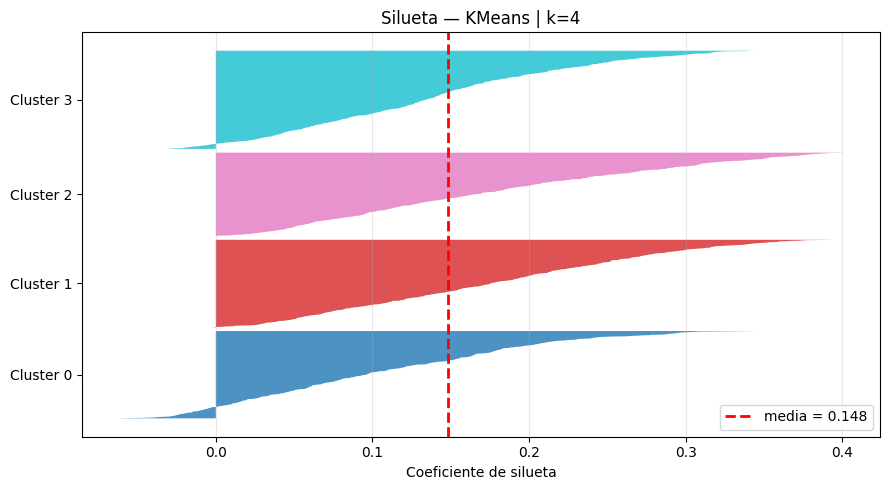

In [ ]:
sil_vals = silhouette_samples(X, labels_final)
sil_media = silhouette_score(X, labels_final)
clusters = sorted(np.unique(labels_final))
colores = plt.cm.tab10(np.linspace(0, 1, len(clusters)))

fig, ax = plt.subplots(figsize=(9, 5))
y = 0
yticks = []
for i, c in enumerate(clusters):
    vals = np.sort(sil_vals[labels_final == c])
    ax.fill_betweenx(range(y, y + len(vals)), 0, vals, facecolor=colores[i], alpha=0.8)
    yticks.append(y + len(vals) / 2)
    y += len(vals) + 20

ax.axvline(sil_media, color="red", linestyle="--", linewidth=2, label=f"media = {sil_media:.3f}")
ax.set_yticks(yticks)
ax.set_yticklabels([f"Cluster {c}" for c in clusters])
ax.set_xlabel("Coeficiente de silueta")
ax.set_title(f"Silueta — {mejor['modelo']} | k={K_OPTIMO}")
ax.legend(loc="best")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. PCA — despliegue de clusters

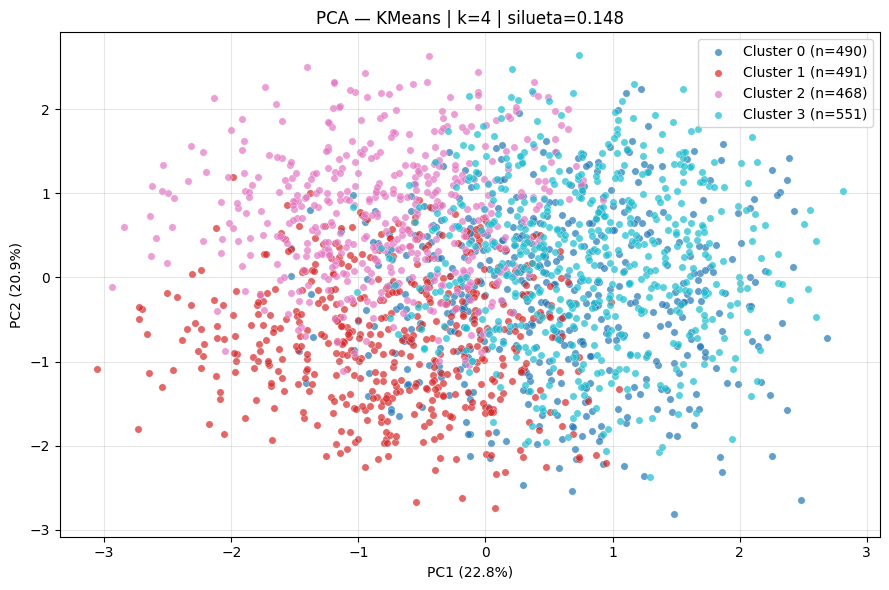

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 6))
for i, c in enumerate(clusters):
    m = labels_final == c
    ax.scatter(
        X_pca[m, 0], X_pca[m, 1],
        s=28, alpha=0.7, color=colores[i],
        edgecolors="white", linewidths=0.3,
        label=f"Cluster {c} (n={m.sum()})",
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"PCA — {mejor['modelo']} | k={K_OPTIMO} | silueta={mejor['silueta']:.3f}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Radar — perfil medio de cada cluster

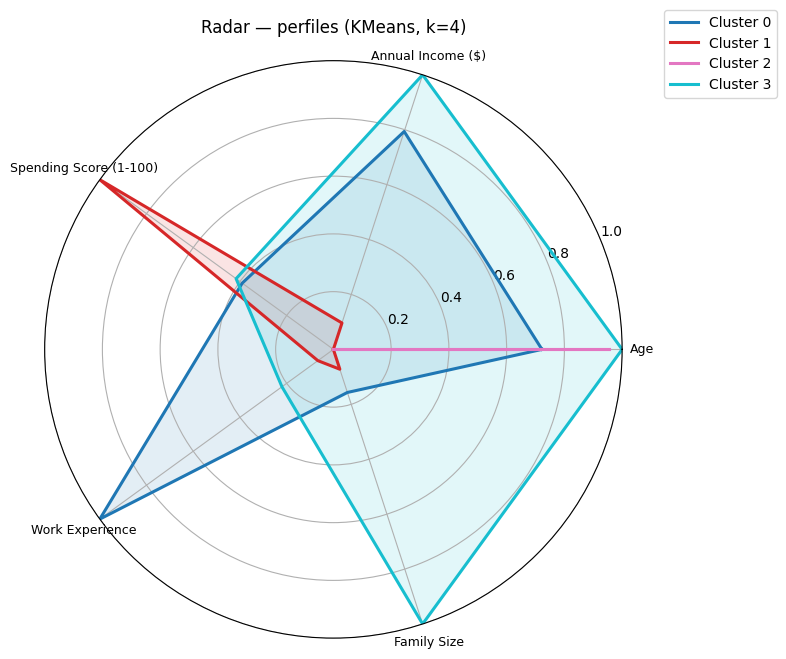

Perfil medio (valores originales):


,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
cluster,,,,,
0,49.38,120144.14,47.46,9.20,3.14
1,42.86,98263.46,80.00,2.18,2.84
2,51.47,95245.10,26.63,1.68,2.59
3,51.89,126626.05,48.86,3.34,6.15


In [ ]:
# Radar con variables interpretables (sin Gender_bin ni dummies)
radar_cols = [
    "Age",
    "Annual Income ($)",
    "Spending Score (1-100)",
    "Work Experience",
    "Family Size",
]
perfil = df.groupby("cluster")[radar_cols].mean()
perfil_n = (perfil - perfil.min()) / (perfil.max() - perfil.min() + 1e-9)

angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, c in enumerate(perfil_n.index):
    vals = perfil_n.loc[c].tolist() + [perfil_n.loc[c].tolist()[0]]
    ax.plot(angles, vals, linewidth=2.2, color=colores[i], label=f"Cluster {c}")
    ax.fill(angles, vals, alpha=0.12, color=colores[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_cols, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title(f"Radar — perfiles ({mejor['modelo']}, k={K_OPTIMO})", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.1))
plt.tight_layout()
plt.show()

print("Perfil medio (valores originales):")
display(perfil.round(2))

## 8. Resumen

In [ ]:
print("=" * 50)
print("RESUMEN FINAL — Customers")
print("=" * 50)
print(f"Método para elegir k : Codo de Jambú")
print(f"k óptimo             : {K_OPTIMO}")
print(f"Mejor algoritmo      : {mejor['modelo']}")
print(f"Mejor silueta        : {mejor['silueta']:.4f}")
print(f"Hiperparámetros      : {mejor['params']}")

RESUMEN FINAL — Customers
Método para elegir k : Codo de Jambú
k óptimo             : 2
Mejor algoritmo      : CJ
Mejor silueta        : 0.3940
Hiperparámetros      : {'linkage': 'complete', 'metric': 'euclidean'}
